In [42]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kirtisharma8433/tweets/Tweets.csv


In [43]:
import pandas as pd
import numpy as np

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Embedding, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [44]:
df = pd.read_csv("/kaggle/input/datasets/kirtisharma8433/tweets/Tweets.csv")

In [45]:
df = df[['text', 'selected_text', 'sentiment']]
df.dropna(inplace=True)

print("Dataset Loaded:", df.shape)

Dataset Loaded: (27480, 3)


# **LSTM TEXT CLASSIFICATION**

In [46]:
# Encode sentiment (positive/negative/neutral)
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

In [47]:
# Tokenization
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['text'])

X = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(X, maxlen=30)

In [48]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build LSTM model
model1 = Sequential()
model1.add(Embedding(5000, 64))
model1.add(LSTM(32))
model1.add(Dense(3, activation='softmax'))

model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [49]:
print("\nTraining LSTM Classification Model...\n")
history1 = model1.fit(X_train, y_train, epochs=2, batch_size=32, validation_split=0.2)

# Evaluate
loss, acc = model1.evaluate(X_test, y_test)
print("\nClassification Accuracy:", acc)


Training LSTM Classification Model...

Epoch 1/2
550/550 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5159 - loss: 0.9568 - val_accuracy: 0.6848 - val_loss: 0.7406
Epoch 2/2
550/550 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7480 - loss: 0.6101 - val_accuracy: 0.6984 - val_loss: 0.7205
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7053 - loss: 0.7027

Classification Accuracy: 0.7036026120185852


# **Sequence to Sequence**

In [50]:
input_texts = df['text'].astype(str)
target_texts = df['selected_text'].astype(str)

# Tokenizers
input_tok = Tokenizer()
target_tok = Tokenizer()

input_tok.fit_on_texts(input_texts)
target_tok.fit_on_texts(target_texts)

In [51]:
# Convert to sequences
encoder_input = input_tok.texts_to_sequences(input_texts)
decoder_input = target_tok.texts_to_sequences(target_texts)

# Padding
encoder_input = pad_sequences(encoder_input, maxlen=30, padding='post')
decoder_input = pad_sequences(decoder_input, maxlen=10, padding='post')



In [52]:
# BUILD SEQ2SEQ MODEL


latent_dim = 64

# Encoder
encoder_inputs = Input(shape=(None,))
enc_emb = Embedding(len(input_tok.word_index)+1, latent_dim)(encoder_inputs)
_, state_h, state_c = LSTM(latent_dim, return_state=True)(enc_emb)

# Decoder
decoder_inputs = Input(shape=(None,))
dec_emb = Embedding(len(target_tok.word_index)+1, latent_dim)(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(
    dec_emb, initial_state=[state_h, state_c]
)

decoder_dense = Dense(len(target_tok.word_index)+1, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)


In [56]:
# Final model
model2 = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy'
)

print("\nTraining Seq2Seq Model...\n")
model2.fit(
    [encoder_input, decoder_input],
    decoder_input,
    epochs=5,
    batch_size=32
)

print("\nSeq2Seq Training Completed!")


Training Seq2Seq Model...

Epoch 1/5
859/859 ━━━━━━━━━━━━━━━━━━━━ 118s 134ms/step - loss: 2.3234
Epoch 2/5
859/859 ━━━━━━━━━━━━━━━━━━━━ 115s 134ms/step - loss: 1.5656
Epoch 3/5
859/859 ━━━━━━━━━━━━━━━━━━━━ 147s 140ms/step - loss: 1.0791
Epoch 4/5
859/859 ━━━━━━━━━━━━━━━━━━━━ 120s 140ms/step - loss: 0.8125
Epoch 5/5
859/859 ━━━━━━━━━━━━━━━━━━━━ 118s 137ms/step - loss: 0.6379

Seq2Seq Training Completed!


In [59]:
# 6. SIMPLE TEST PREDICTION (OPTIONAL)


sample_text = ["I am very happy today"]

sample_seq = tokenizer.texts_to_sequences(sample_text)
sample_seq = pad_sequences(sample_seq, maxlen=30)

pred = model1.predict(sample_seq)
print("\nSample Sentiment Prediction:", le.inverse_transform([np.argmax(pred)]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Sample Sentiment Prediction: ['positive']


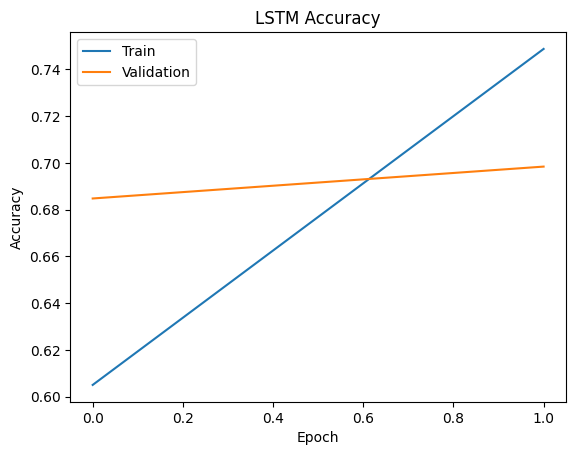

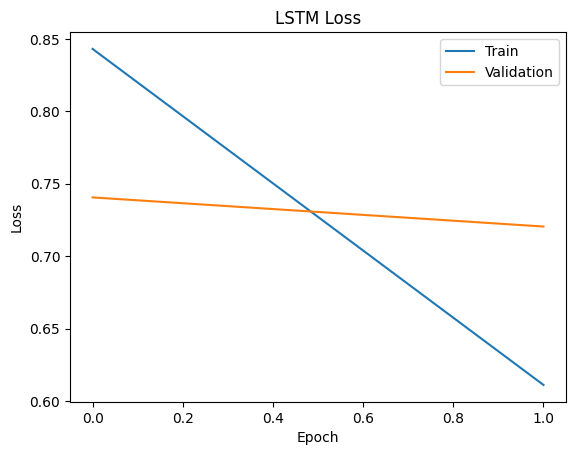

In [62]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure()
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss Graph
plt.figure()
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()